#### Librerias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#### Parametros

In [2]:
PATH_PROJECT = 'C:/Users/vatec/OneDrive/Documentos/Hans/Cursos/5 CODERHOUSE - Data Science II - Machine Learning para la Ciencia de Datos Flex/Material/Proyectos/Template Model Project DS/'


PATH = PATH_PROJECT +'data/processed/'



#### Lectura

In [3]:
df = pd.read_csv(f'{PATH}dataset_merged_processed.csv')

In [4]:
df.head(1)

,ID,systolic,relaxation,Cholesterol,triglyceride,HDL,LDL,gender,age,height(cm),...,tartar,eyesight(left)_x,eyesight(right)_x,hearing(left)_x,hearing(right)_x,eyesight(left)_y,eyesight(right)_y,hearing(left)_y,hearing(right)_y,target
0,0,4.75,3.041667,8.958333,3.416667,3.041667,5.25,F,40.0,155.0,...,Y,0.043056,0.041667,0.041667,0.041667,0.043056,0.041667,0.041667,0.041667,0


In [5]:
df["target"] = df["target"].map({0:"NO FUMADOR", 1:"FUMADOR"})

In [6]:
df.sample(5)

,ID,systolic,relaxation,Cholesterol,triglyceride,HDL,LDL,gender,age,height(cm),...,tartar,eyesight(left)_x,eyesight(right)_x,hearing(left)_x,hearing(right)_x,eyesight(left)_y,eyesight(right)_y,hearing(left)_y,hearing(right)_y,target
28063,35025,5.416667,3.083333,8.375000,5.375000,2.625000,4.666667,M,25.0,175.0,...,Y,0.041667,0.003472,0.041667,0.041667,0.041667,0.003472,0.041667,0.041667,NO FUMADOR
16518,20585,4.958333,3.083333,9.583333,2.791667,2.250000,6.791667,F,60.0,155.0,...,N,0.043056,0.004861,0.041667,0.041667,0.043056,0.004861,0.041667,0.041667,NO FUMADOR
37274,46571,4.583333,2.916667,6.916667,2.333333,2.083333,4.375000,M,25.0,170.0,...,Y,0.041667,0.004861,0.041667,0.041667,0.041667,0.004861,0.041667,0.041667,NO FUMADOR
37563,46935,5.750000,3.583333,6.041667,8.833333,2.208333,2.041667,M,45.0,175.0,...,N,0.003472,0.004861,0.041667,0.041667,0.003472,0.004861,0.041667,0.041667,FUMADOR
15908,19834,5.333333,3.125000,9.625000,7.458333,2.333333,6.125000,M,30.0,180.0,...,Y,0.041667,0.006250,0.041667,0.041667,0.041667,0.006250,0.041667,0.041667,NO FUMADOR


#### EDA

In [7]:
df.describe()

,ID,systolic,relaxation,Cholesterol,triglyceride,HDL,LDL,age,height(cm),weight(kg),...,Gtp,dental caries,eyesight(left)_x,eyesight(right)_x,hearing(left)_x,hearing(right)_x,eyesight(left)_y,eyesight(right)_y,hearing(left)_y,hearing(right)_y
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,26284.994580,5.062688,3.167519,8.206039,5.275309,2.387391,4.791840,44.188155,164.646278,65.877008,...,1.667899,0.213120,0.028450,0.028276,0.042737,0.042758,0.028450,0.028276,0.042737,0.042758
std,16015.070567,0.567825,0.401889,1.506033,2.980229,0.609557,1.698239,12.028283,9.172001,12.817799,...,2.104838,0.409516,0.023898,0.023940,0.006586,0.006640,0.023898,0.023940,0.006586,0.006640
min,0.000000,2.958333,1.666667,2.291667,0.333333,0.166667,0.041667,20.000000,130.000000,30.000000,...,0.041667,0.000000,0.000694,0.000694,0.041667,0.041667,0.000694,0.000694,0.041667,0.041667
25%,12499.750000,4.666667,2.916667,7.166667,3.083333,1.958333,3.833333,40.000000,160.000000,55.000000,...,0.708333,0.000000,0.005556,0.005556,0.041667,0.041667,0.005556,0.005556,0.041667,0.041667
50%,24999.500000,5.000000,3.166667,8.166667,4.500000,2.333333,4.750000,40.000000,165.000000,65.000000,...,1.083333,0.000000,0.041667,0.041667,0.041667,0.041667,0.041667,0.041667,0.041667,0.041667
75%,40034.250000,5.416667,3.416667,9.125000,6.666667,2.708333,5.625000,55.000000,170.000000,75.000000,...,1.833333,0.000000,0.043056,0.043056,0.041667,0.041667,0.043056,0.043056,0.041667,0.041667
max,55690.000000,10.000000,6.083333,18.541667,41.625000,25.750000,77.500000,85.000000,190.000000,135.000000,...,41.625000,1.000000,0.381250,0.381250,0.083333,0.083333,0.381250,0.381250,0.083333,0.083333


In [8]:
target_counts = df.target.value_counts(normalize=True)*100

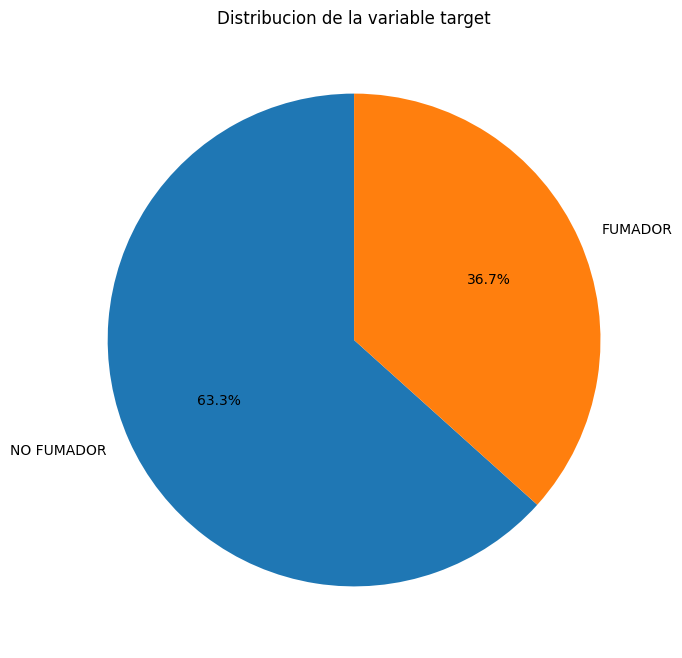

In [9]:
plt.figure(figsize=(8,8))
plt.pie(target_counts, labels=target_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Distribucion de la variable target")
plt.show()

In [11]:
object_columns = df.select_dtypes(include=["object"]).columns

C:\Users\vatec\AppData\Local\Temp\ipykernel_8788\3745126527.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns = df.select_dtypes(include=["object"]).columns


In [12]:
object_columns

Index(['gender', 'tartar', 'target'], dtype='str')

In [13]:
object_columns = object_columns.drop("target")

In [15]:
object_columns

Index(['gender', 'tartar'], dtype='str')

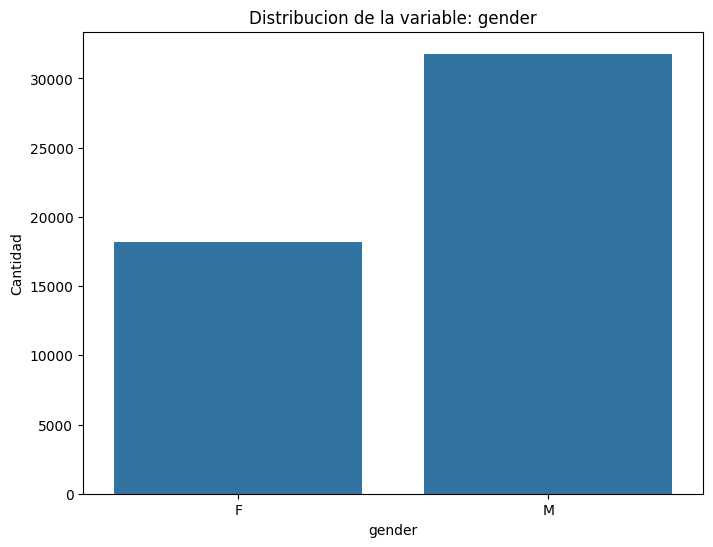

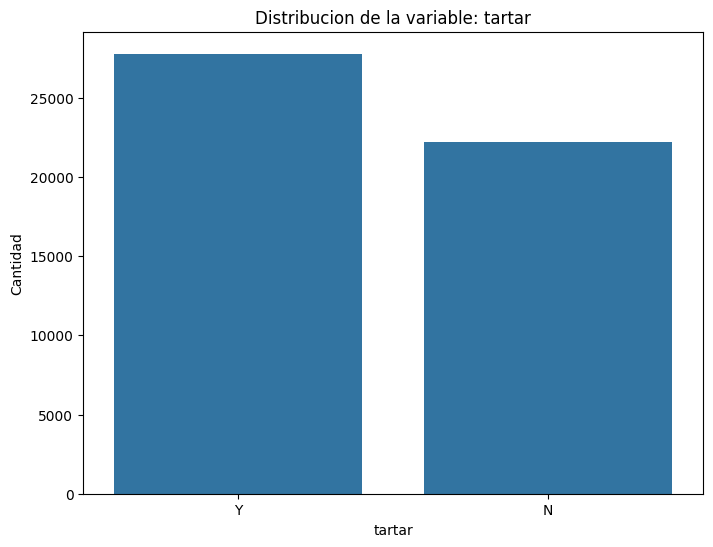

In [16]:
for column in object_columns:
    plt.figure(figsize=(8,6))
    sns.countplot(data=df, x=column)
    plt.title(f"Distribucion de la variable: {column}")
    plt.xlabel(column)
    plt.ylabel("Cantidad")
    plt.show()

In [17]:
df.tartar.value_counts()

tartar
Y    27789
N    22211
Name: count, dtype: int64

In [18]:
df.gender.value_counts()

gender
M    31788
F    18212
Name: count, dtype: int64

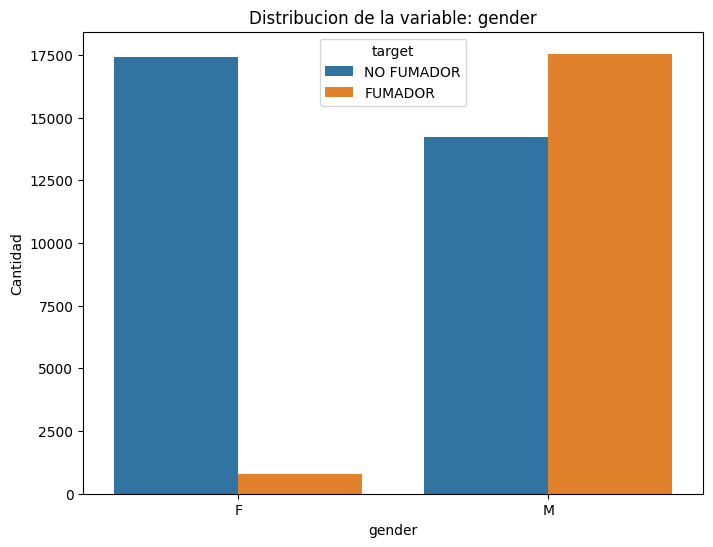

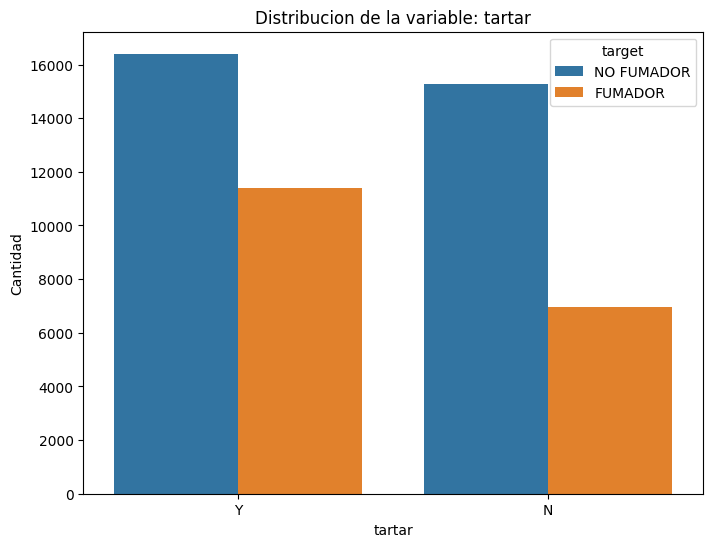

In [19]:
for column in object_columns:
    plt.figure(figsize=(8,6))
    sns.countplot(data=df, x=column, hue="target")
    plt.title(f"Distribucion de la variable: {column}")
    plt.xlabel(column)
    plt.ylabel("Cantidad")
    plt.show()

In [20]:
df.describe()

,ID,systolic,relaxation,Cholesterol,triglyceride,HDL,LDL,age,height(cm),weight(kg),...,Gtp,dental caries,eyesight(left)_x,eyesight(right)_x,hearing(left)_x,hearing(right)_x,eyesight(left)_y,eyesight(right)_y,hearing(left)_y,hearing(right)_y
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,26284.994580,5.062688,3.167519,8.206039,5.275309,2.387391,4.791840,44.188155,164.646278,65.877008,...,1.667899,0.213120,0.028450,0.028276,0.042737,0.042758,0.028450,0.028276,0.042737,0.042758
std,16015.070567,0.567825,0.401889,1.506033,2.980229,0.609557,1.698239,12.028283,9.172001,12.817799,...,2.104838,0.409516,0.023898,0.023940,0.006586,0.006640,0.023898,0.023940,0.006586,0.006640
min,0.000000,2.958333,1.666667,2.291667,0.333333,0.166667,0.041667,20.000000,130.000000,30.000000,...,0.041667,0.000000,0.000694,0.000694,0.041667,0.041667,0.000694,0.000694,0.041667,0.041667
25%,12499.750000,4.666667,2.916667,7.166667,3.083333,1.958333,3.833333,40.000000,160.000000,55.000000,...,0.708333,0.000000,0.005556,0.005556,0.041667,0.041667,0.005556,0.005556,0.041667,0.041667
50%,24999.500000,5.000000,3.166667,8.166667,4.500000,2.333333,4.750000,40.000000,165.000000,65.000000,...,1.083333,0.000000,0.041667,0.041667,0.041667,0.041667,0.041667,0.041667,0.041667,0.041667
75%,40034.250000,5.416667,3.416667,9.125000,6.666667,2.708333,5.625000,55.000000,170.000000,75.000000,...,1.833333,0.000000,0.043056,0.043056,0.041667,0.041667,0.043056,0.043056,0.041667,0.041667
max,55690.000000,10.000000,6.083333,18.541667,41.625000,25.750000,77.500000,85.000000,190.000000,135.000000,...,41.625000,1.000000,0.381250,0.381250,0.083333,0.083333,0.381250,0.381250,0.083333,0.083333


#### Distribuciones

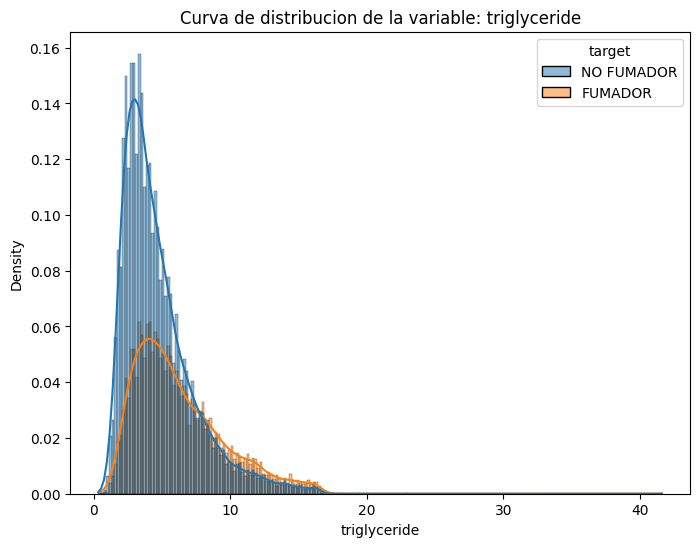

In [21]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x = "triglyceride", kde=True, hue="target", stat="density")
plt.title("Curva de distribucion de la variable: triglyceride")
plt.show()

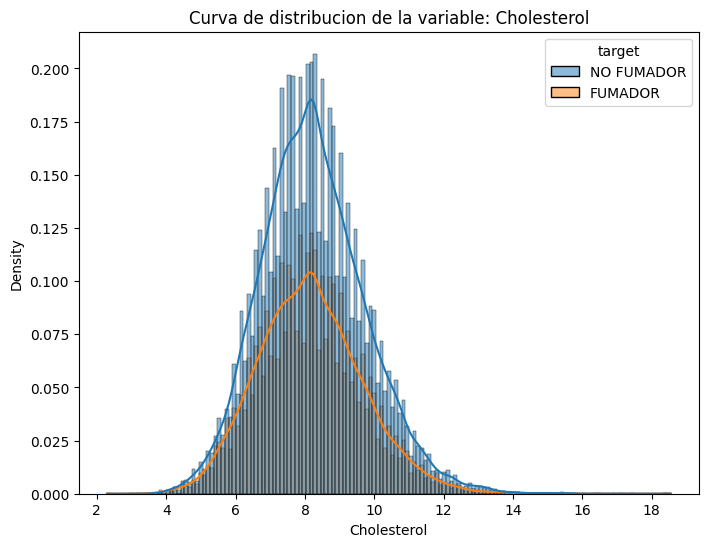

In [22]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x = "Cholesterol", kde=True, hue="target", stat="density")
plt.title("Curva de distribucion de la variable: Cholesterol")
plt.show()

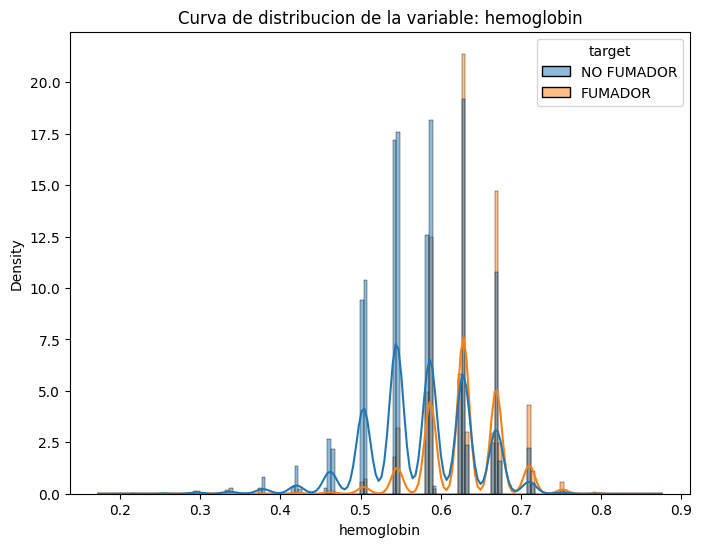

In [23]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x = "hemoglobin", kde=True, hue="target", stat="density")
plt.title("Curva de distribucion de la variable: hemoglobin")
plt.show()

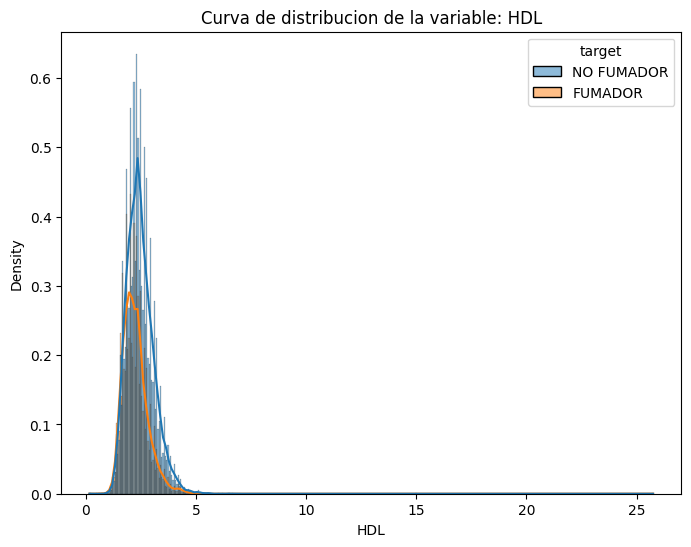

In [24]:
plt.figure(figsize=(8,6))
sns.histplot(data=df, x = "HDL", kde=True, hue="target", stat="density")
plt.title("Curva de distribucion de la variable: HDL")
plt.show()

#### Boxplots

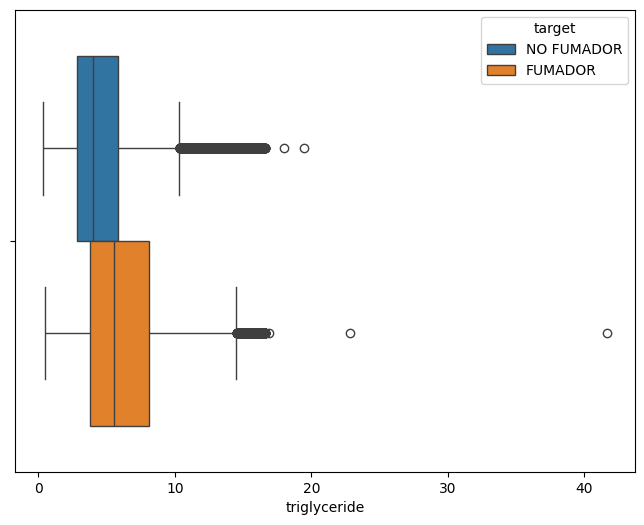

In [25]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x = "triglyceride", hue="target")
plt.show()

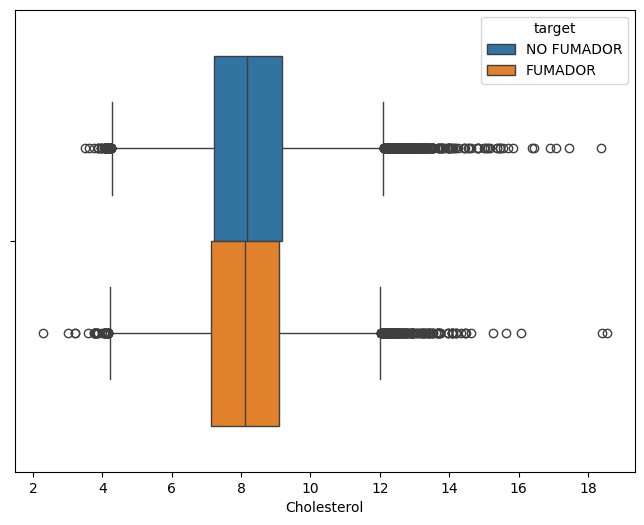

In [26]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x = "Cholesterol", hue="target")
plt.show()

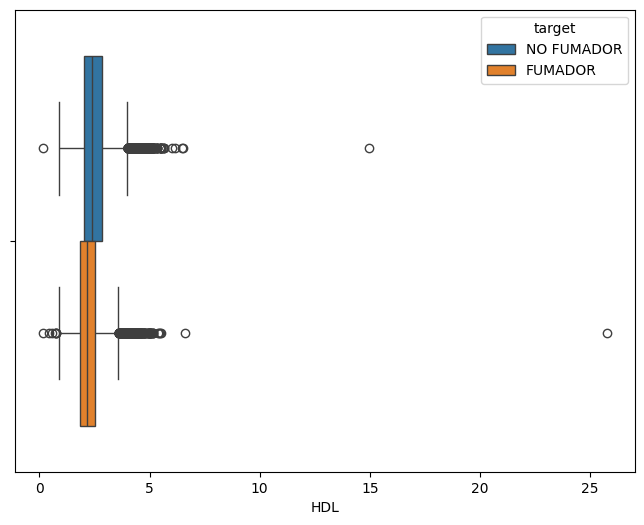

In [27]:
plt.figure(figsize=(8,6))
sns.boxplot(data=df, x = "HDL", hue="target")
plt.show()

#### Scatterplots

In [28]:
df.columns

Index(['ID', 'systolic', 'relaxation', 'Cholesterol', 'triglyceride', 'HDL',
       'LDL', 'gender', 'age', 'height(cm)', 'weight(kg)', 'waist(cm)',
       'fasting blood sugar', 'hemoglobin', 'Urine protein',
       'serum creatinine', 'ALT', 'Gtp', 'dental caries', 'tartar',
       'eyesight(left)_x', 'eyesight(right)_x', 'hearing(left)_x',
       'hearing(right)_x', 'eyesight(left)_y', 'eyesight(right)_y',
       'hearing(left)_y', 'hearing(right)_y', 'target'],
      dtype='str')

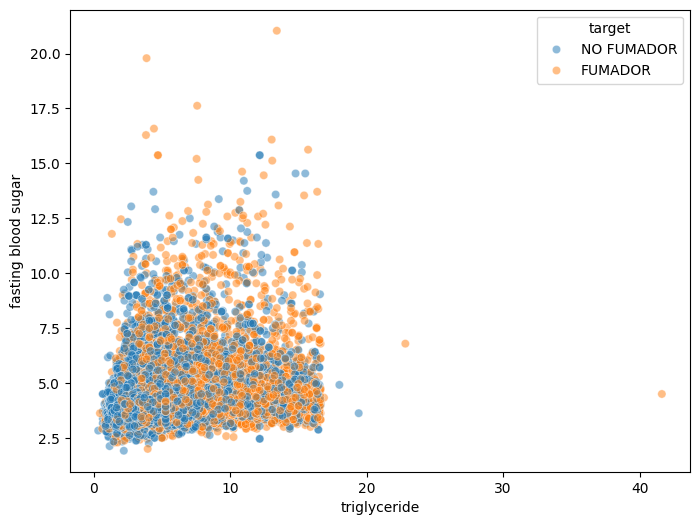

In [29]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x = "triglyceride", y="fasting blood sugar", hue="target", alpha=0.5)
plt.show()

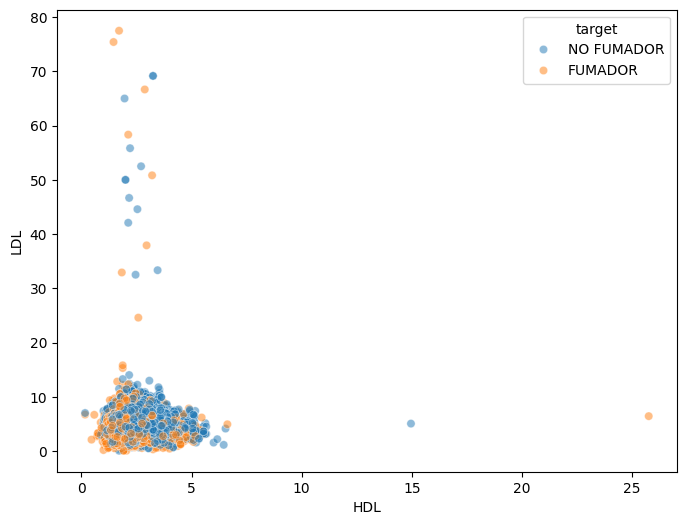

In [30]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x = "HDL", y="LDL", hue="target", alpha=0.5)
plt.show()

#### Correlacion

In [31]:
df["target"] = df["target"].map({"NO FUMADOR": 0, "FUMADOR": 1})

In [32]:
df_corr = df.select_dtypes(include="number").corr()

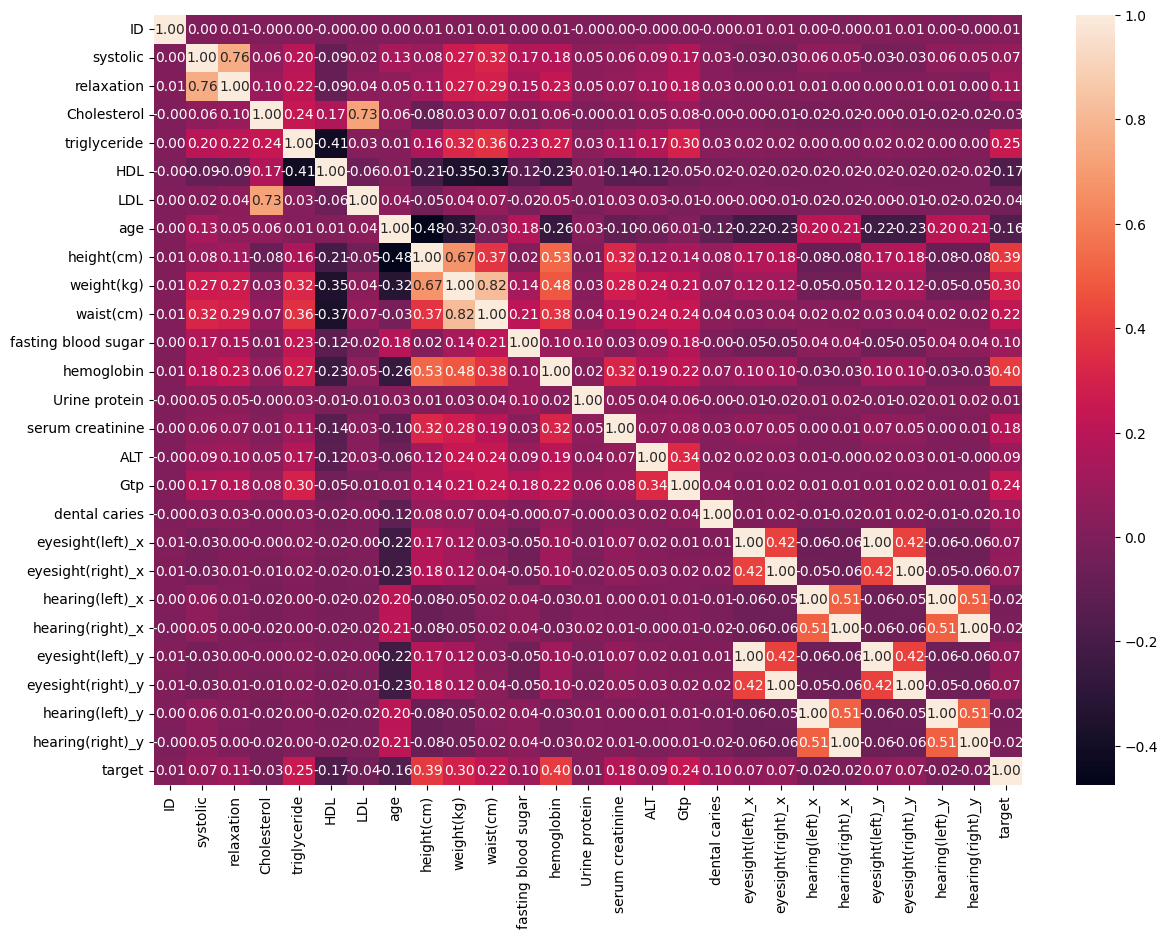

In [33]:
plt.figure(figsize=(14,10))
sns.heatmap(df_corr,annot=True, fmt=".2f")
plt.show()

In [35]:
# filtramos df_0 y df_1
df_0 = df[df["target"] == 0]
df_1 = df[df["target"] == 1]

# correlaciones
df_corr_0 = df_0.select_dtypes(include="number").corr()
df_corr_1 = df_1.select_dtypes(include="number").corr()

df_corr_0 
df_corr_1

,ID,systolic,relaxation,Cholesterol,triglyceride,HDL,LDL,age,height(cm),weight(kg),...,dental caries,eyesight(left)_x,eyesight(right)_x,hearing(left)_x,hearing(right)_x,eyesight(left)_y,eyesight(right)_y,hearing(left)_y,hearing(right)_y,target
ID,1.000000,0.002449,0.004320,-0.004535,-0.002827,0.003288,-0.002790,0.001555,0.013565,0.004291,...,-0.007696,0.008108,0.005992,0.001421,-0.015549,0.008108,0.005992,0.001421,-0.015549,NaN
systolic,0.002449,1.000000,0.754057,0.083430,0.168252,-0.018151,0.009739,0.102879,0.031310,0.232360,...,0.014328,-0.026464,-0.009551,0.016784,0.003205,-0.026464,-0.009551,0.016784,0.003205,NaN
relaxation,0.004320,0.754057,1.000000,0.118116,0.188713,-0.026240,0.031482,0.061962,0.042192,0.224062,...,0.008273,-0.000066,0.014020,-0.014426,-0.029303,-0.000066,0.014020,-0.014426,-0.029303,NaN
Cholesterol,-0.004535,0.083430,0.118116,1.000000,0.293484,0.098795,0.702014,0.019536,-0.010732,0.107858,...,-0.002610,0.022934,0.018147,-0.031393,-0.026858,0.022934,0.018147,-0.031393,-0.026858,NaN
triglyceride,-0.002827,0.168252,0.188713,0.293484,1.000000,-0.352577,0.016634,0.082172,0.016377,0.248886,...,-0.016013,0.012420,0.001057,-0.000730,-0.009490,0.012420,0.001057,-0.000730,-0.009490,NaN
HDL,0.003288,-0.018151,-0.026240,0.098795,-0.352577,1.000000,-0.089713,-0.062272,-0.063736,-0.285119,...,0.011113,0.015266,0.000575,-0.023172,-0.013716,0.015266,0.000575,-0.023172,-0.013716,NaN
LDL,-0.002790,0.009739,0.031482,0.702014,0.016634,-0.089713,1.000000,0.014131,0.002511,0.094854,...,-0.000591,0.008376,0.009401,-0.020713,-0.017074,0.008376,0.009401,-0.020713,-0.017074,NaN
age,0.001555,0.102879,0.061962,0.019536,0.082172,-0.062272,0.014131,1.000000,-0.379927,-0.252383,...,-0.132155,-0.175058,-0.160355,0.184420,0.193065,-0.175058,-0.160355,0.184420,0.193065,NaN
height(cm),0.013565,0.031310,0.042192,-0.010732,0.016377,-0.063736,0.002511,-0.379927,1.000000,0.532677,...,0.044815,0.095151,0.099271,-0.092522,-0.083080,0.095151,0.099271,-0.092522,-0.083080,NaN
weight(kg),0.004291,0.232360,0.224062,0.107858,0.248886,-0.285119,0.094854,-0.252383,0.532677,1.000000,...,0.029042,0.064926,0.075157,-0.067451,-0.061971,0.064926,0.075157,-0.067451,-0.061971,NaN


#### Output

In [36]:
df.to_csv(PATH_PROJECT + "data/processed/dataset_merged_processed_eda.csv", index=False)